# 03 — Extract Landmarks

## What this notebook does
Loops MediaPipe over every image in the ASL Alphabet dataset (~87,000 images) and saves the extracted hand landmarks into a single clean CSV file.

## Why we do this
We can't train a model on raw photos — they don't generalise to a live camera.
Instead we convert each photo into 63 numbers (the hand geometry) and train on those.

This notebook does that conversion once and saves the result.
You never have to run this again unless you change the dataset.

## What goes in, what comes out

In [3]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

## Step 1 — Set up paths and MediaPipe

We point to the ASL Alphabet dataset folder and initialise MediaPipe.

We use `static_image_mode=True` because we're processing individual photos, not a video stream.
`min_detection_confidence=0.5` means MediaPipe needs to be at least 50% sure it found a hand — if it's less confident than that, it skips the image. That's fine, we'd rather skip than save bad data.

In [4]:
# Paths
DATASET_PATH = '../data/raw/asl_alphabet/asl_alphabet_train'
OUTPUT_PATH  = '../data/processed/landmarks.csv'

os.makedirs('../data/processed', exist_ok=True)

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task",
    "hand_landmarker.task"
)

base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5
)
landmarker = vision.HandLandmarker.create_from_options(options)

classes = sorted(os.listdir(DATASET_PATH))
print(f"Classes found: {len(classes)}")
print(f"Classes: {classes}")

Classes found: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Step 2 — Count total images

Before we start the big loop, let's count exactly how many images we're working with across all classes. This helps us track progress and know what to expect.

In [5]:
total_images = 0
class_counts = {}

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len(os.listdir(cls_path))
    class_counts[cls] = count
    total_images += count

print(f"Total images to process: {total_images:,}")
print(f"\nImages per class:")
for cls, count in class_counts.items():
    print(f"  {cls}: {count}")

Total images to process: 87,000

Images per class:
  A: 3000
  B: 3000
  C: 3000
  D: 3000
  E: 3000
  F: 3000
  G: 3000
  H: 3000
  I: 3000
  J: 3000
  K: 3000
  L: 3000
  M: 3000
  N: 3000
  O: 3000
  P: 3000
  Q: 3000
  R: 3000
  S: 3000
  T: 3000
  U: 3000
  V: 3000
  W: 3000
  X: 3000
  Y: 3000
  Z: 3000
  del: 3000
  nothing: 3000
  space: 3000


## Step 3 — Extract landmarks from all images

This is the main loop. For every image in every class folder we:
1. Read the image
2. Run MediaPipe on it
3. If a hand is detected — extract the 63 values and save with the label
4. If no hand is detected — skip that image (don't save anything)

`tqdm` gives us a progress bar so we can see how far through we are.

> ⏱ This will take a few minutes. Don't close the notebook while it runs.

In [6]:
data    = []
skipped = 0
saved   = 0

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images   = os.listdir(cls_path)

    for img_file in tqdm(images, desc=f"Processing {cls}", leave=False):
        img_path = os.path.join(cls_path, img_file)
        img      = cv2.imread(img_path)

        if img is None:
            skipped += 1
            continue

        img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mp_image  = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        results   = landmarker.detect(mp_image)

        if results.hand_landmarks:
            landmarks = []
            for lm in results.hand_landmarks[0]:
                landmarks.extend([lm.x, lm.y, lm.z])

            data.append([cls] + landmarks)
            saved += 1
        else:
            skipped += 1

landmarker.close()

print(f"\n✅ Done")
print(f"   Saved:   {saved:,} images")
print(f"   Skipped: {skipped:,} images (no hand detected)")
print(f"   Success rate: {saved/total_images*100:.1f}%")


✅ Done
   Saved:   63,580 images
   Skipped: 23,420 images (no hand detected)
   Success rate: 73.1%


## Step 4 — Build the DataFrame and save to CSV

We now have a list of rows. Each row is `[label, x0, y0, z0, x1, y1, z1, ... x20, y20, z20]`.

We turn that into a proper DataFrame with named columns and save it as a CSV.

The column names follow the pattern: `x0, y0, z0, x1, y1, z1, ...` — so column `x4` is the x coordinate of landmark point 4 (the thumb tip), `x8` is the index fingertip, and so on.

In [7]:
# Build column names: label + x0,y0,z0, x1,y1,z1 ... x20,y20,z20
columns = ['label']
for i in range(21):
    columns += [f'x{i}', f'y{i}', f'z{i}']

df = pd.DataFrame(data, columns=columns)

print("DataFrame shape:", df.shape)
print("\nFirst few rows:")
df.head()

DataFrame shape: (63580, 64)

First few rows:


,label,x0,y0,z0,x1,y1,z1,x2,y2,z2,...,z17,x18,y18,z18,x19,y19,z19,x20,y20,z20
0,A,0.441170,0.579908,-1.463700e-07,0.565186,0.508961,-0.030005,0.634230,0.383416,-0.041656,...,-0.049812,0.381163,0.317218,-0.105233,0.392002,0.400469,-0.095807,0.393709,0.453162,-0.072677
1,A,0.477503,0.609889,-2.625951e-07,0.592091,0.544300,-0.033601,0.670831,0.415301,-0.049104,...,-0.067616,0.422880,0.355803,-0.113152,0.431145,0.438622,-0.103791,0.429101,0.487164,-0.084636
2,A,0.715760,0.672876,-3.593083e-07,0.803339,0.618436,-0.028361,0.853366,0.509800,-0.036164,...,-0.034534,0.627855,0.458478,-0.075215,0.635363,0.514935,-0.071314,0.644623,0.561842,-0.055937
3,A,0.658861,0.756222,-5.324430e-08,0.816351,0.664612,-0.039513,0.895912,0.505532,-0.056701,...,-0.067503,0.605805,0.452790,-0.127372,0.629957,0.541381,-0.123739,0.635879,0.598962,-0.106496
4,A,0.659470,0.770520,-3.571306e-08,0.815303,0.683091,-0.042204,0.897008,0.523745,-0.059607,...,-0.060773,0.610748,0.460467,-0.125922,0.633412,0.551274,-0.125219,0.639890,0.613800,-0.108605


## Step 5 — Validate the data

Before saving, let's check the quality of what we extracted:
- Are there any missing values?
- How many samples per class?
- Is it balanced across letters?

A balanced dataset means roughly the same number of samples per letter. If one letter has 3,000 samples and another has 200, the model will be biased toward the letter with more data.

In [8]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Samples per class
print("\nSamples per label:")
label_counts = df['label'].value_counts().sort_index()
print(label_counts)

# Quick balance check
print(f"\nMin samples in any class: {label_counts.min()}")
print(f"Max samples in any class: {label_counts.max()}")
print(f"Difference: {label_counts.max() - label_counts.min()}")

Missing values: 0

Samples per label:
label
A          2182
B          2202
C          1962
D          2457
E          2307
F          2864
G          2428
H          2373
I          2379
J          2571
K          2699
L          2521
M          1603
N          1275
O          2258
P          2040
Q          2118
R          2545
S          2555
T          2354
U          2509
V          2548
W          2453
X          2156
Y          2580
Z          2343
del        1773
nothing       1
space      1524
Name: count, dtype: int64

Min samples in any class: 1
Max samples in any class: 2864
Difference: 2863


## Step 6 — Visualise class balance

A bar chart makes it easy to spot any badly imbalanced classes at a glance.

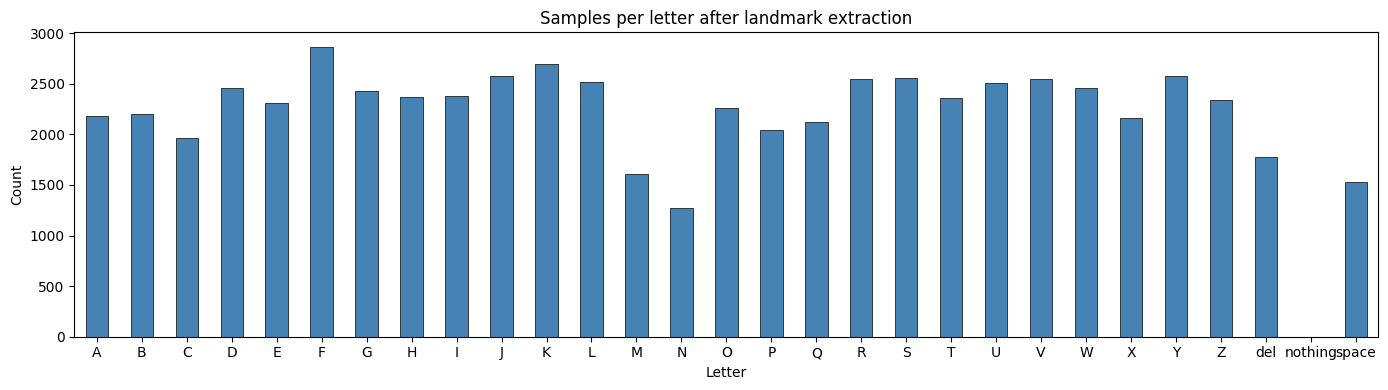

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Samples per letter after landmark extraction')
plt.xlabel('Letter')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 7 — Save to CSV

Save the cleaned landmark data to `data/processed/landmarks.csv`.

This file is gitignored — it's generated data, not source code. Anyone cloning the repo can regenerate it by running this notebook.

In [10]:
df.to_csv(OUTPUT_PATH, index=False)

# Confirm the file was saved
file_size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"✅ Saved to: {OUTPUT_PATH}")
print(f"   Rows:      {len(df):,}")
print(f"   Columns:   {len(df.columns)}")
print(f"   File size: {file_size_mb:.1f} MB")

✅ Saved to: ../data/processed/landmarks.csv
   Rows:      63,580
   Columns:   64
   File size: 75.8 MB


## Step 8 — Quick sanity check on the saved file

Reload the CSV from disk and confirm it reads back correctly. Never assume a save worked — always verify.

In [11]:
# Reload and verify
df_check = pd.read_csv(OUTPUT_PATH)

print("Reloaded shape:", df_check.shape)
print("Labels present:", sorted(df_check['label'].unique()))
print("Any nulls:", df_check.isnull().sum().sum())
print("\nSample row (label + first 9 landmark values):")
print(df_check.iloc[0, :10])

Reloaded shape: (63580, 64)
Labels present: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Any nulls: 0

Sample row (label + first 9 landmark values):
label           A
x0        0.44117
y0       0.579908
z0           -0.0
x1       0.565186
y1       0.508961
z1      -0.030005
x2        0.63423
y2       0.383416
z2      -0.041656
Name: 0, dtype: object


## ✅ Notebook complete

**What we built:**
- Looped MediaPipe over ~87,000 ASL Alphabet images
- Extracted 63 landmark values per image
- Skipped images where no hand was detected
- Saved everything to `data/processed/landmarks.csv`

**What that file contains:**
- One row per image
- 64 columns — 1 label + 63 landmark values (x, y, z × 21 points)
- Clean, no nulls, ready for training

**What's next:**
Open `04_train_letters.ipynb` — we load this CSV, train a Random Forest classifier, evaluate accuracy, and save the model to `models/letter_model.pkl`.

Read `docs/04_train_letters.md` before starting the next notebook.